In [1]:
"""PEPS boundary-contraction notebook experiments."""
# pylint: disable=wrong-import-position
import os
from time import perf_counter

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp")
from IPython.display import display
import quimb.tensor as qtn

import pepsy as py
core = py.core

import torch


In [2]:
to_backend = core.backend_torch(dtype=torch.complex128)
optimizer = core.build_optimizer(progbar=True, directory="cash/", parallel=True)


In [3]:
Lx, Ly = 4, 4
state = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=6, dtype="complex128")
pepo = qtn.PEPO.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=6, dtype="complex128")
p = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=66, dtype="complex128")
reference_state = core.tns_align(p, pepo)


# state = core.add_cycle(state, 2)
# reference_state = core.add_cycle(reference_state, 3)


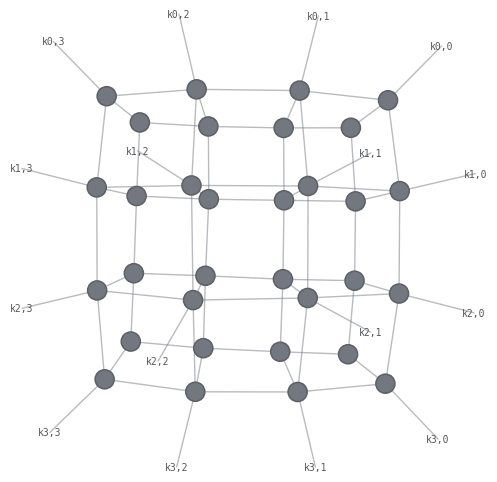

In [4]:
reference_state.draw()

In [5]:
display(state)

PEPS(tensors=16, indices=40, Lx=4, Ly=4, max_bond=2)

In [6]:
# build_bra_ket API smoke test (norm + mps_boundaries)
ket_test, norm_input = py.build_bra_ket(
    ket=state,
    bra=reference_state,
)
norm_input.apply_to_arrays(to_backend)


In [7]:
print(id(ket_test) == id(state))


True


In [8]:
display(norm_input)


TensorNetwork2D(tensors=48, indices=104, Lx=4, Ly=4, max_bond=2)

In [9]:
# Return boundary MPSs.
boundary_mps = py.BdyMPS(
    tn_double=norm_input,
    chi=20,
    single_layer=False,
)


In [10]:
# Retune all boundary MPS bonds to target chi (expand or compress as needed).
boundary_mps.expand_bnd(32)
boundary_mps.normalize()
display((boundary_mps.norm, boundary_mps.chi))


(tensor(1.-7.4959e-18j, dtype=torch.complex128), 32)

In [11]:
boundary_mps.show("Y2_l")

grid cut=Y2 (direction=y, side=left)
Y3  ○──○──○──○
    │  │  │  │
Y2  ●> ●> ●> ●
    │  │  │  │
Y1  ○──○──○──○
    │  │  │  │
Y0  ○──○──○──○
    X0 X1 X2 X3

│8│32│32│
>─>──>──●
│ │  │  │


In [12]:
print(boundary_mps.mps_b["Y0_l"].norm())
boundary_mps.mps_b["Y0_l"].show()


tensor(1.-7.4959e-18j, dtype=torch.complex128)
 8 32 32 
>─>──>──●
│ │  │  │


In [13]:
# Retune all boundary MPS bonds to target chi (expand or compress as needed).
boundary_mps.expand_bnd(64)
boundary_mps.normalize()
display((boundary_mps.norm, boundary_mps.chi))


(tensor(1.-1.0270e-18j, dtype=torch.complex128), 64)

In [14]:
boundary_mps.show("Y1_r")


grid cut=Y2 (direction=y, side=right)
Y3  ○──○──○──○
    │  │  │  │
Y2  ● <● <● <●
    │  │  │  │
Y1  ○──○──○──○
    │  │  │  │
Y0  ○──○──○──○
    X0 X1 X2 X3

│8│64│64│
>─>──>──●
│ │  │  │


In [15]:
norm_value = norm_input.contract(all, optimize=optimizer)
print(complex(norm_value))


(-2.2592545454387834e+23+5.45946670240866e+22j)


In [16]:
boundary_result = py.contract_boundary(
    norm=norm_input,
    mps_boundaries=boundary_mps.mps_b,
    contraction_opt=optimizer,
    n_iter=1,
    progress=True,
    direction="y",
    visualize=False,
    max_separation=0,
    track_boundary_fidelity=True,
)

display(boundary_result)


bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=64, F=1]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=64, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00, 23.46it/s, chi=64, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00, 23.22it/s, chi=64, F=1]

...

bdy_dmrg::  50%|█████     | 2/4 [00:00<00:00, 35.53it/s, chi=64, F=1]

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 37.94it/s, chi=64, F=1]

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 37.71it/s, chi=64, F=1]

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 49.99it/s, chi=64, F=1]

BoundaryContractResult(cost=tensor(-2.2593e+23+5.4595e+22j, dtype=torch.complex128), fidel=[0.9999999999999998, 0.9999999999999998, 1.0000000000000004, 0.9999999999999999], direction='y', n_iter=1, max_separation=0)

In [17]:
display(boundary_mps.norm)


tensor(6.4457e+11+1.4954e-05j, dtype=torch.complex128)

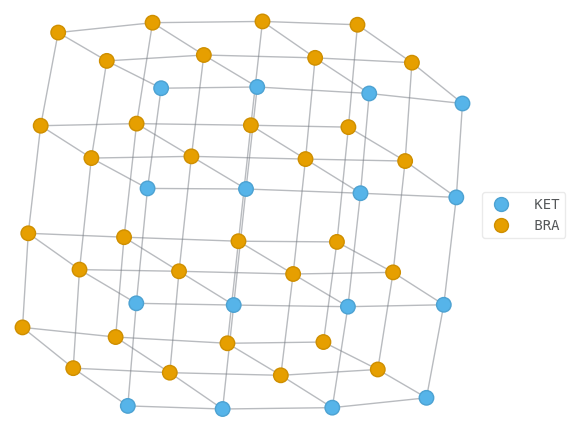

In [18]:
norm_input.draw(["KET","BRA"])

In [19]:
start_time = perf_counter()
reference_value = norm_input.contract_boundary(
    max_bond=20,
    mode="mps",
    final_contract_opts={"optimize": optimizer},
    cutoff=1e-14,
    progbar=True,
    #layer_tags=["KET", "BRA"],
    max_separation=0,
)
print(f"contract_boundary elapsed: {perf_counter() - start_time:.3f}s")
display(reference_value)


0it [00:00, ?it/s]

contracting boundary, Lx=4, Ly=4: : 0it [00:00, ?it/s]

contracting xmin, Lx=4, Ly=4: : 0it [00:00, ?it/s]    

contracting xmax, Lx=3, Ly=4: : 1it [00:00, 23.60it/s]

contracting xmin, Lx=2, Ly=4: : 2it [00:00, 34.33it/s]

contracted boundary, Lx=1, Ly=4: : 3it [00:00, 48.14it/s]

contracted boundary, Lx=1, Ly=4: : 3it [00:00, 47.64it/s]

contract_boundary elapsed: 0.067s


tensor(-2.1639e+23+4.7001e+22j, dtype=torch.complex128)

In [20]:
cost_result = py.contract_boundary(
    norm=norm_input,
    mps_boundaries=boundary_mps.mps_b,
    contraction_opt=optimizer,
    n_iter=5,
    progress=True,
    track_boundary_fidelity=True,
    visualize=False,
    direction="y",
    retag=True,
    max_separation=0,
)

display(cost_result)


bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=64, F=1]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=64, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00,  5.25it/s, chi=64, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00,  5.21it/s, chi=64, F=1]

...

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 10.38it/s, chi=64, F=1]

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 10.38it/s, chi=64, F=1]

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 11.97it/s, chi=64, F=1]

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 11.68it/s, chi=64, F=1]

BoundaryContractResult(cost=tensor(-2.2593e+23+5.4595e+22j, dtype=torch.complex128), fidel=[1.0, 1.0000000000000007, 1.0000000000000004, 1.0000000000000004], direction='y', n_iter=5, max_separation=0)

In [21]:
display(boundary_mps.norm)


tensor(6.4457e+11-1.1483e-05j, dtype=torch.complex128)

In [22]:
display(state)


PEPS(tensors=16, indices=40, Lx=4, Ly=4, max_bond=2)

In [23]:
old_norm = py.normalize(
    state,
    chi=32,
    contraction_opt=optimizer,
    max_separation=0,
    n_iter=5,
    direction="y",
    progress=True,
    track_boundary_fidelity=True,
)
display(old_norm)


bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=16, F=1]

bdy_dmrg::   0%|          | 0/4 [00:00<?, ?it/s, chi=16, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00, 10.16it/s, chi=16, F=1]

bdy_dmrg::  25%|██▌       | 1/4 [00:00<00:00, 10.09it/s, chi=16, F=1]

...

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 22.49it/s, chi=16, F=1]

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 22.49it/s, chi=16, F=1]

bdy_dmrg::  75%|███████▌  | 3/4 [00:00<00:00, 22.49it/s, chi=16, F=1]

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 23.53it/s, chi=16, F=1]

tensor(2.6852e+17-101.1558j, dtype=torch.complex128)

In [24]:
optimizer = core.build_optimizer(progbar=False, directory=None, parallel=False)

p = qtn.PEPS.rand(Lx=5, Ly=5, bond_dim=2, seed=6, dtype="complex128")
state_scale = (p.H & p).contract(all, optimize=optimizer)
p.multiply_(1 / state_scale**0.5)
old_norm = py.normalize(
    p,
    chi=32,
    contraction_opt=optimizer,
    max_separation=0,
    n_iter=5,
    direction="y",
    progress=False,
    track_boundary_fidelity=False,
)
cost = complex(old_norm)
cost

(0.999999999999998+4.625292931890907e-16j)

In [25]:
p = qtn.PEPS.rand(Lx=5, Ly=4, bond_dim=4, seed=6, dtype="complex128")
p_target = qtn.PEPS.rand(Lx=5, Ly=4, bond_dim=3, seed=6, dtype="complex128")
p_target = p.compress_all(max_bond=3)


p.apply_to_arrays(to_backend)
p_target.apply_to_arrays(to_backend)


In [26]:
res = py.infidelity(
    p,
    p_target,
    chi=60,
    contraction_opt=optimizer,
    # norm=4.717020e+30+1.663490e+27j,
    # norm_target=2.341571e+29+1.058935e+24j,
    n_iter=5,
    direction="y",
    max_separation=1,
    progress=True,
)
print(f"boundary infidelity = {res['infidelity']:.6e}")
print(f"<p|p>               = {res['norm']:.6e}")
print(f"<p_t|p_t>           = {res['norm_target']:.6e}")
print(f"<p_t|p>             = {res['overlap']:.6e}")

bdy_dmrg::   0%|          | 0/3 [00:00<?, ?it/s]

bdy_dmrg::   0%|          | 0/3 [00:00<?, ?it/s, chi=60]

bdy_dmrg::   0%|          | 0/3 [00:00<?, ?it/s, chi=60]

bdy_dmrg::  33%|███▎      | 1/3 [00:00<00:00,  5.61it/s, chi=60]

bdy_dmrg::  33%|███▎      | 1/3 [00:00<00:00,  5.61it/s, chi=60]

...

bdy_dmrg::  67%|██████▋   | 2/3 [00:00<00:00,  7.99it/s, chi=60]

bdy_dmrg::  67%|██████▋   | 2/3 [00:00<00:00,  7.99it/s, chi=60]

bdy_dmrg:: 100%|██████████| 3/3 [00:00<00:00,  2.98it/s, chi=60]

bdy_dmrg:: 100%|██████████| 3/3 [00:00<00:00,  3.18it/s, chi=60]

boundary infidelity = 9.506583e-01
<p|p>               = 4.717020e+30+1.663490e+27j
<p_t|p_t>           = 2.341571e+29+1.058935e+24j
<p_t|p>             = 2.333765e+29+5.873716e+27j


In [27]:
# --- exact infidelity via full contraction ---
norm_tn = p.H & p
norm_target_tn = p_target.H & p_target
overlap_tn = p.H & p_target

norm_val = norm_tn.contract(all, optimize=optimizer)
norm_target_val = norm_target_tn.contract(all, optimize=optimizer)
overlap_val = overlap_tn.contract(all, optimize=optimizer)

exact_infidelity = 1 - abs(overlap_val) ** 2 / (abs(norm_val) * abs(norm_target_val))
print(f"exact infidelity    = {float(exact_infidelity):.6e}")
print(f"<p|p>               = {complex(norm_val):.6e}")
print(f"<p_t|p_t>           = {complex(norm_target_val):.6e}")
print(f"<p_t|p>             = {complex(overlap_val):.6e}")

exact infidelity    = 9.506910e-01
<p|p>               = 4.724692e+30+3.958242e+13j
<p_t|p_t>           = 2.341573e+29-4.727900e+13j
<p_t|p>             = 2.334830e+29-6.107936e+27j
